### Mean and median imputation

If data is normally distributed then we can fill na with mean . But when distribution is skwed then we use median .

**When to use this imputation** => When missing value is less than 5% and in random places.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer


In [2]:
df = pd.read_csv(r'C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\tested.csv' , usecols=['Age' , 'Fare' , 'Survived' ,'SibSp' , 'Parch' ])

In [3]:
df.head()

,Survived,Age,SibSp,Parch,Fare
0,0,34.5,0,0,7.8292
1,1,47.0,1,0,7.0000
2,0,62.0,0,0,9.6875
3,0,27.0,0,0,8.6625
4,1,22.0,1,1,12.2875


In [4]:
df.isnull().mean()*100

Survived     0.000000
Age         20.574163
SibSp        0.000000
Parch        0.000000
Fare         0.239234
dtype: float64

In [5]:
Family = pd.DataFrame(np.sum(df[['SibSp' , 'Parch']] , axis=1))

In [6]:
df.join(Family)

,Survived,Age,SibSp,Parch,Fare,0
0,0,34.5,0,0,7.8292,0
1,1,47.0,1,0,7.0000,1
2,0,62.0,0,0,9.6875,0
3,0,27.0,0,0,8.6625,0
4,1,22.0,1,1,12.2875,2
...,...,...,...,...,...,...
413,0,NaN,0,0,8.0500,0
414,1,39.0,0,0,108.9000,0
415,0,38.5,0,0,7.2500,0
416,0,NaN,0,0,8.0500,0


In [59]:

def clean_data(df):
    df = df.drop(columns=['SibSp'])
    df = df.drop(columns=['Parch'])
    df = df.rename(columns={0: 'Family'})
    return df
df = df.join(Family)

new_df = clean_data(df)
new_df.head()

,Survived,Age,Fare,Family
0,0,34.5,7.8292,0
1,1,47.0,7.0000,2
2,0,62.0,9.6875,0
3,0,27.0,8.6625,0
4,1,22.0,12.2875,2


Now working on this new_df

In [60]:
new_df.isnull().mean()*100

Survived     0.000000
Age         20.574163
Fare         0.239234
Family       0.000000
dtype: float64

In [61]:
x= new_df.drop(columns=['Survived'])
y = new_df['Survived']

In [62]:
x_train , x_test , y_train, y_test = train_test_split(x , y , test_size=0.2 , random_state=42 , stratify=y)

In [63]:
x_train.isnull().mean()

Age       0.206587
Fare      0.002994
Family    0.000000
dtype: float64

In [64]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()

mean_Fare = x_train['Fare'].mean()
median_Fare = x_train['Fare'].median()


In [65]:
x_train['Age_mean'] = x_train['Age'].fillna(np.ceil(mean_age))
x_train['Age_median'] = x_train['Age'].fillna(median_age)

x_train['fare_mean'] = x_train['Fare'].fillna(np.ceil(mean_Fare))
x_train['fare_median'] = x_train['Fare'].fillna(median_Fare)

In [66]:
x_train.sample(5)

,Age,Fare,Family,Age_mean,Age_median,fare_mean,fare_median
192,11.5,14.5000,2,11.5,11.5,14.5000,14.5000
358,NaN,7.7500,0,31.0,27.0,7.7500,7.7500
109,18.5,13.0000,0,18.5,18.5,13.0000,13.0000
279,22.0,10.5000,0,22.0,22.0,10.5000,10.5000
173,NaN,7.2292,0,31.0,27.0,7.2292,7.2292


In [67]:
print('Original Age variable variance' , x_train['Age'].var())
print('Age variance after mean imputation' , x_train['Age_mean'].var())
print('Age variance after median imputation' , x_train['Age_median'].var())

print('Original Fare variable variance' , x_train['Fare'].var())
print('Fare variance after mean imputation' , x_train['fare_mean'].var())
print('Fare variance after median imputation' , x_train['fare_median'].var())

Original Age variable variance 205.81458596340764
Age variance after mean imputation 163.21387801334268
Age variance after median imputation 165.15194781967597
Original Fare variable variance 3358.2181906021965
Fare variance after mean imputation 3348.1342361119246
Fare variance after median imputation 3349.6780051319915


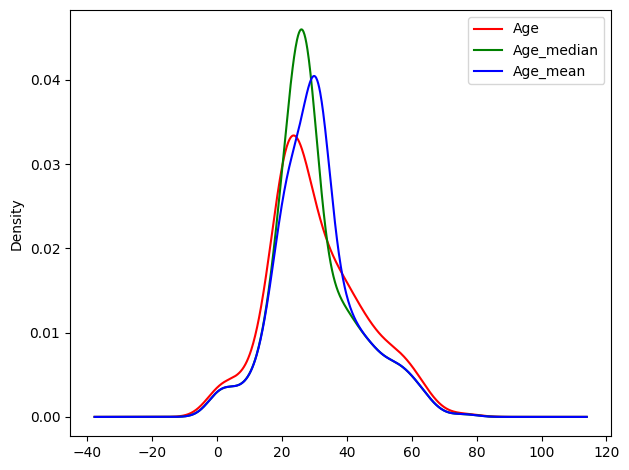

In [68]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Age'].plot(kind = 'kde' , ax = ax , color = "red")
x_train['Age_median'].plot(kind = 'kde' , ax = ax , color = "green")
x_train['Age_mean'].plot(kind = 'kde' , ax = ax , color = "blue")
plt.tight_layout()
plt.legend()
plt.show()


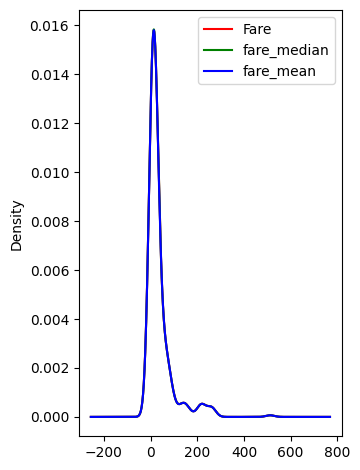

In [69]:
fig = plt.figure()
ax = fig.add_subplot(121)

x_train['Fare'].plot(kind='kde', ax=ax, color="red")
x_train['fare_median'].plot(kind='kde', ax=ax, color="green")
x_train['fare_mean'].plot(kind='kde', ax=ax, color="blue")
plt.tight_layout()
plt.legend()
plt.show()

In [70]:
x_train.cov()

,Age,Fare,Family,Age_mean,Age_median,fare_mean,fare_median
Age,205.814586,297.433363,-1.543779,205.814586,205.814586,295.721499,293.079971
Fare,297.433363,3358.218191,19.083859,232.737567,250.732220,3358.218191,3358.218191
Family,-1.543779,19.083859,3.366996,-1.259840,-0.986728,19.025196,19.086588
Age_mean,205.814586,232.737567,-1.259840,163.213878,162.867705,232.084653,229.998053
Age_median,205.814586,250.732220,-0.986728,162.867705,165.151948,250.026539,247.882306
fare_mean,295.721499,3358.218191,19.025196,232.084653,250.026539,3348.134236,3348.098635
fare_median,293.079971,3358.218191,19.086588,229.998053,247.882306,3348.098635,3349.678005


### Using Sklearn

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [72]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [74]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder='passthrough')

In [75]:
trf.fit(x_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [76]:
trf.named_transformers_['imputer1'].statistics_

array([27.])

In [77]:
trf.named_transformers_['imputer2'].statistics_

array([36.48801351])

In [78]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [79]:
x_train

array([[27.    ,  7.    ,  0.    ],
       [21.    ,  7.7958,  0.    ],
       [27.    ,  7.75  ,  0.    ],
       ...,
       [ 0.83  ,  9.35  ,  0.    ],
       [27.    ,  8.05  ,  0.    ],
       [40.5   , 15.1   ,  0.    ]], shape=(334, 3))

### Arbitrary Value Imputation – Data Science Technique

---

#### What is Arbitrary Value Imputation?

- **Arbitrary value imputation** is a method for handling missing values in a dataset.
- Instead of filling missing values with the mean, median, or mode, you fill them with a **fixed value chosen by the user** (e.g., -999, 0, or 999).
- The chosen value should be **distinct and unlikely to occur naturally** in your data, so it stands out as a placeholder for missingness.

---

#### Why Use Arbitrary Value Imputation?

- **Flags missing values** so the model can notice them.
- Allows machine learning models (especially tree-based models) to learn patterns that relate to missingness.
- Useful when **missingness itself might be informative** for prediction.
- Commonly used to indicate missingness explicitly, so the model can treat missing values differently.

---

#### When to Use Arbitrary Value Imputation?

- When the fact that a value is missing could be important for prediction.
- When you want models to treat missing values as a separate category.
- When other imputation methods (mean, median, mode) may distort the data.

---


## Pros and Cons

**Pros:**
- Simple and easy to implement.
- Makes missingness visible to models.
- Can help models capture patterns due to missingness.

**Cons:**
- If not handled carefully, arbitrary values can confuse some algorithms (especially linear models).
- May not be suitable for all datasets or problem types.
- Can introduce outliers if the arbitrary value is not chosen wisely.

---


In [84]:
x = new_df.drop(columns=['Survived'])
y = new_df['Survived']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)
x_train['Age_99'] = x_train['Age'].fillna(99)
x_train['Age_minus1'] = x_train['Age'].fillna(-1)

x_train['Fare_999'] = x_train['Fare'].fillna(999)
x_train['Fare_minus1'] = x_train['Fare'].fillna(-1)

In [85]:
print('Original Age variable variance', x_train['Age'].var())
print('Age variance after mean imputation', x_train['Age_99'].var())
print('Age variance after median imputation', x_train['Age_minus1'].var())

print('Original Fare variable variance', x_train['Fare'].var())
print('Fare variance after mean imputation', x_train['Fare_999'].var())
print('Fare variance after median imputation', x_train['Fare_minus1'].var())

Original Age variable variance 205.81458596340764
Age variance after mean imputation 935.1736341766917
Age variance after median imputation 326.02166783909666
Original Fare variable variance 3358.2181906021965
Fare variance after mean imputation 6121.8739426987495
Fare variance after median imputation 3352.3410894862564


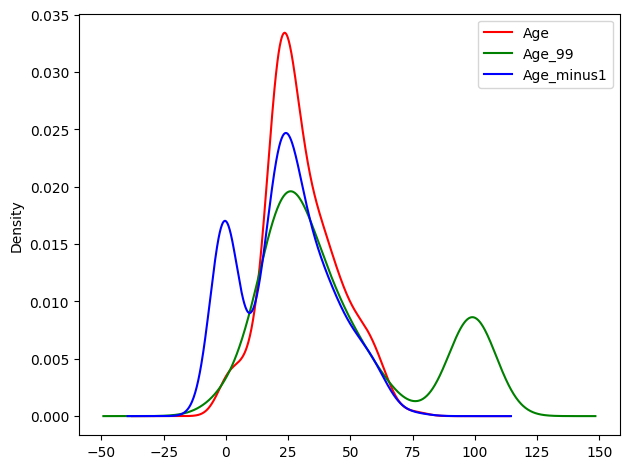

In [86]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Age'].plot(kind='kde', ax=ax, color="red")
x_train['Age_99'].plot(kind='kde', ax=ax, color="green")
x_train['Age_minus1'].plot(kind='kde', ax=ax, color="blue")
plt.tight_layout()
plt.legend()
plt.show()

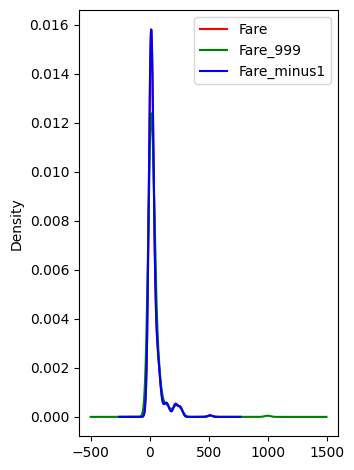

In [88]:
fig = plt.figure()
ax = fig.add_subplot(121)

x_train['Fare'].plot(kind='kde', ax=ax, color="red")
x_train['Fare_999'].plot(kind='kde', ax=ax, color="green")
x_train['Fare_minus1'].plot(kind='kde', ax=ax, color="blue")
plt.tight_layout()
plt.legend()
plt.show()

In [89]:
x_train.cov()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,205.814586,297.433363,-1.543779,205.814586,205.814586,405.135936,291.399515
Fare,297.433363,3358.218191,19.083859,-73.171541,376.694794,3358.218191,3358.218191
Family,-1.543779,19.083859,3.366996,-5.902734,0.925052,16.482282,19.125644
Age_99,205.814586,-73.171541,-5.902734,935.173634,-191.406988,-27.081432,-74.738371
Age_minus1,205.814586,376.694794,0.925052,-191.406988,326.021668,481.146354,371.451330
Fare_999,405.135936,3358.218191,16.482282,-27.081432,481.146354,6121.873943,3240.101528
Fare_minus1,291.399515,3358.218191,19.125644,-74.738371,371.451330,3240.101528,3352.341089


In [91]:
x_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,1.000000,0.328565,-0.060884,1.000000,1.000000,0.326665,0.320141
Fare,0.328565,1.000000,0.179262,-0.041244,0.361703,1.000000,1.000000
Family,-0.060884,0.179262,1.000000,-0.105193,0.027920,0.114803,0.180020
Age_99,1.000000,-0.041244,-0.105193,1.000000,-0.346648,-0.011318,-0.042211
Age_minus1,1.000000,0.361703,0.027920,-0.346648,1.000000,0.340574,0.355308
Fare_999,0.326665,1.000000,0.114803,-0.011318,0.340574,1.000000,0.715224
Fare_minus1,0.320141,1.000000,0.180020,-0.042211,0.355308,0.715224,1.000000


### Using Sklearn

In [92]:
x = new_df.drop(columns=['Survived'])
y = new_df['Survived']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)

imputer1 = SimpleImputer(strategy='constant', fill_value=99)
imputer2 = SimpleImputer(strategy='constant', fill_value=999)

In [93]:
trf = ColumnTransformer([
    ('imputer1' , imputer1 , ['Age']),
    ('imputer2' , imputer2 , ['Fare'])
], remainder='passthrough')

In [94]:
trf.fit(x_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [95]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [96]:
x_train

array([[99.    ,  7.    ,  0.    ],
       [21.    ,  7.7958,  0.    ],
       [99.    ,  7.75  ,  0.    ],
       ...,
       [ 0.83  ,  9.35  ,  0.    ],
       [99.    ,  8.05  ,  0.    ],
       [40.5   , 15.1   ,  0.    ]], shape=(334, 3))

### End of Distribution Imputation – Data Science Technique

---

#### What is End of Distribution Imputation?

- **End of distribution imputation** is a method for handling missing values in a dataset.
- Instead of using the mean, median, or mode, you fill missing values with an **extreme value at the end of the data’s distribution**.
- The imputed value is typically much larger (or smaller) than any normal value in the feature/column.

---

#### Why Use End of Distribution Imputation?

- **Flags missing values** by making them stand out as outliers.
- Helps tree-based models recognize and split on missingness.
- Useful when you want the model to easily "notice" missing values as a special case.
- Especially helpful for features where the presence of missingness may be informative.

---

#### When to Use End of Distribution Imputation?

- When missingness itself might carry information for prediction.
- When you want to avoid distorting the distribution with mean/median imputation.
- When the feature’s values are numeric and have a clear range or limit.
- Often used in tree-based algorithms (like decision trees, random forests).

---

#### How to Implement in Python (pandas/NumPy)?

Suppose you want to impute missing values with the **maximum value plus a constant** (for upper-end imputation):

```python
import numpy as np
import pandas as pd

# Example DataFrame
df = pd.DataFrame({'income': [35000, np.nan, 50000, 42000, np.nan, 62000]})

# Impute missing with max + 1000 (end of distribution)
max_val = df['income'].max()
imputed_val = max_val + 1000
df['income_imputed'] = df['income'].fillna(imputed_val)
print(df)
```

**Output:**
```
   income  income_imputed
0  35000.0        35000.0
1      NaN        63000.0
2  50000.0        50000.0
3  42000.0        42000.0
4      NaN        63000.0
5  62000.0        62000.0
```

- You can also use **minimum value minus a constant** for lower-end imputation.

---

#### Pros and Cons

**Pros:**
- Simple to implement.
- Makes missingness obvious to certain ML models.
- Can help tree-based models split on missing values.

**Cons:**
- Can create extreme outliers, which may confuse linear or distance-based models.
- Not suitable for all data types or algorithms.
- Should be used with caution for features with a wide range.

---

## Summary

- End of distribution imputation = filling missing values with a value at the extreme end of the feature’s range (max + k or min - k).
- Makes missing values stand out.
- Best for tree-based and rule-based models, or when missingness is informative.

---